In [39]:
%pylab inline
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
from itertools import product
import seaborn as sns
from pmdarima import auto_arima

def invboxcox(y,lmbda):
   if lmbda == 0:
      return(np.exp(y))
   else:
      return(np.exp(np.log(lmbda*y+1)/lmbda))

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [40]:
df = pd.read_csv('salary.csv',sep = ';', index_col=['month'], parse_dates=['month'], dayfirst=True)
df.head()

,salary
month,
1993-01-01,15.3
1993-02-01,19.1
1993-03-01,23.6
1993-04-01,30.6
1993-05-01,37.5


Text(0.5, 0, 'Год')

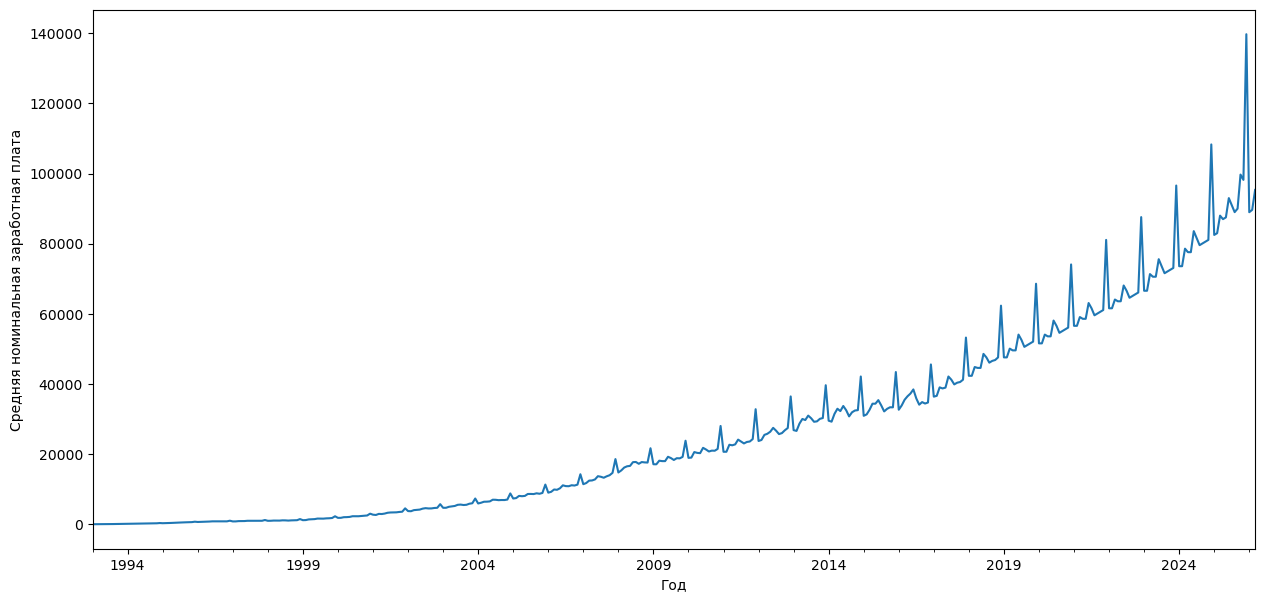

In [41]:
plt.figure(figsize(15,7))
df.salary.plot()
plt.ylabel(u'Средняя номинальная заработная плата')
plt.xlabel(u'Год')

In [42]:
# проверка стационарности 

print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(df.salary)[1])

# Данные нестационарны

Критерий Дики-Фуллера: p=0.998621


<Figure size 1500x1000 with 0 Axes>

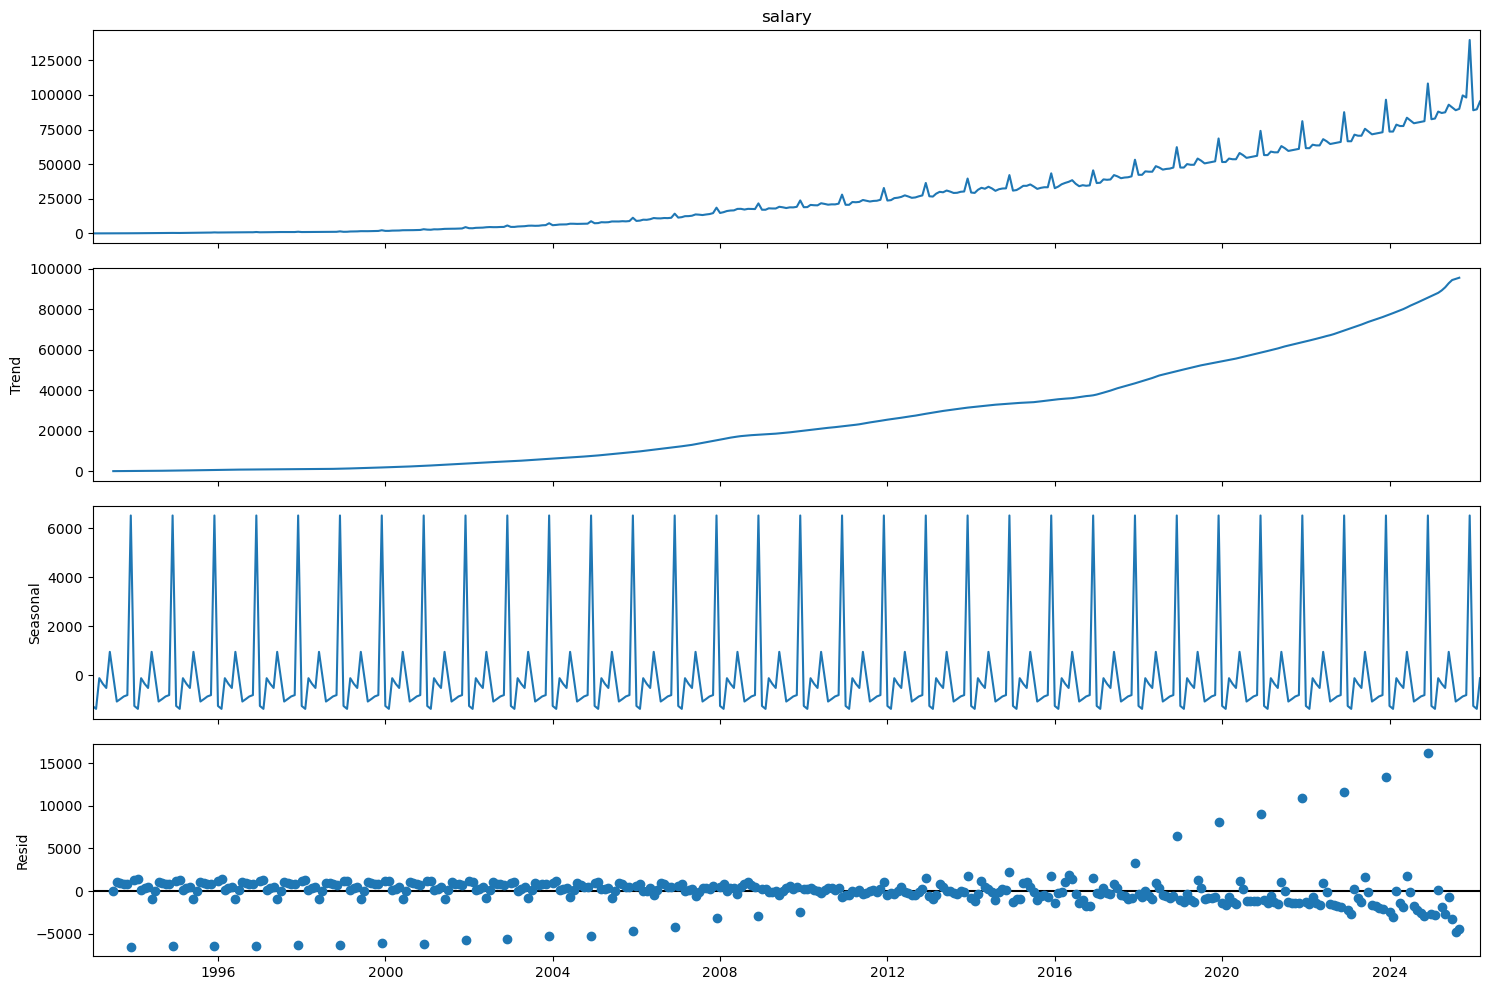

In [43]:
# тренд и сезонность

plt.figure(figsize(15,10))
sm.tsa.seasonal_decompose(df.salary).plot()
plt.show()

In [44]:
# плавное долгосрочное увеличение уровня.
# циклическое изменение уровня с постоянным периодом.
# дисперсия значений в начале значительно меньше дисперсии значений в конце.

# стационировать данные!

# стабилизировать дисперсию в течении всего ряда.
# провести дифференцирование 

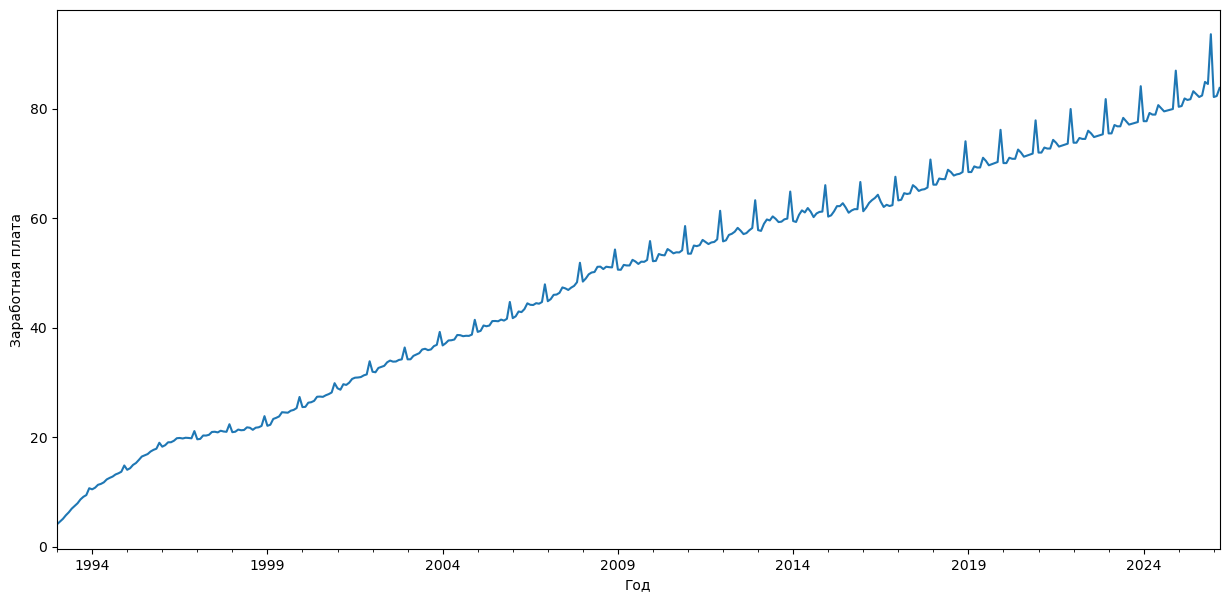

In [45]:
# Для нормального распределения

df['salary_boxcox'], lmbda = stats.boxcox(df.salary)
plt.figure(figsize(15,7))
df.salary_boxcox.plot()
plt.ylabel(u'Заработная плата')
plt.xlabel(u'Год')
plt.show()

In [46]:
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(df.salary_boxcox)[1])

Критерий Дики-Фуллера: p=0.868714


<Figure size 1500x1000 with 0 Axes>

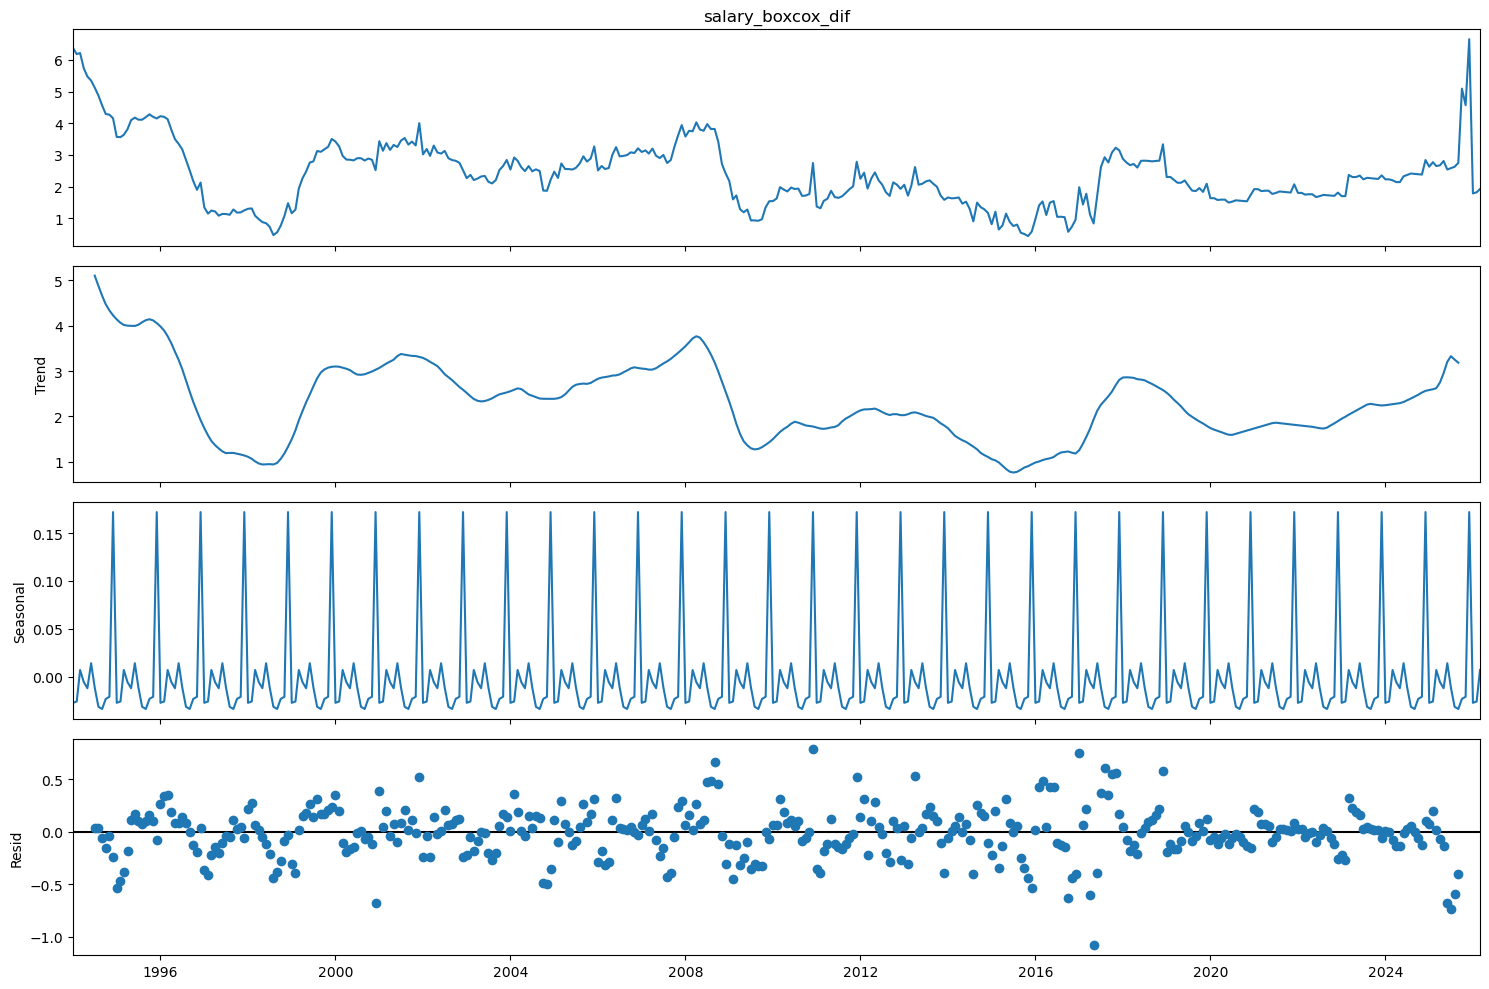

In [47]:
# сезонное дифференцирование

df['salary_boxcox_dif'] = df.salary_boxcox - df.salary_boxcox.shift(12)
plt.figure(figsize(15,10))
sm.tsa.seasonal_decompose(df.salary_boxcox_dif[12:]).plot()
plt.show()

In [48]:
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(df.salary_boxcox_dif[12:])[1])


Критерий Дики-Фуллера: p=0.001415


<Figure size 1500x1000 with 0 Axes>

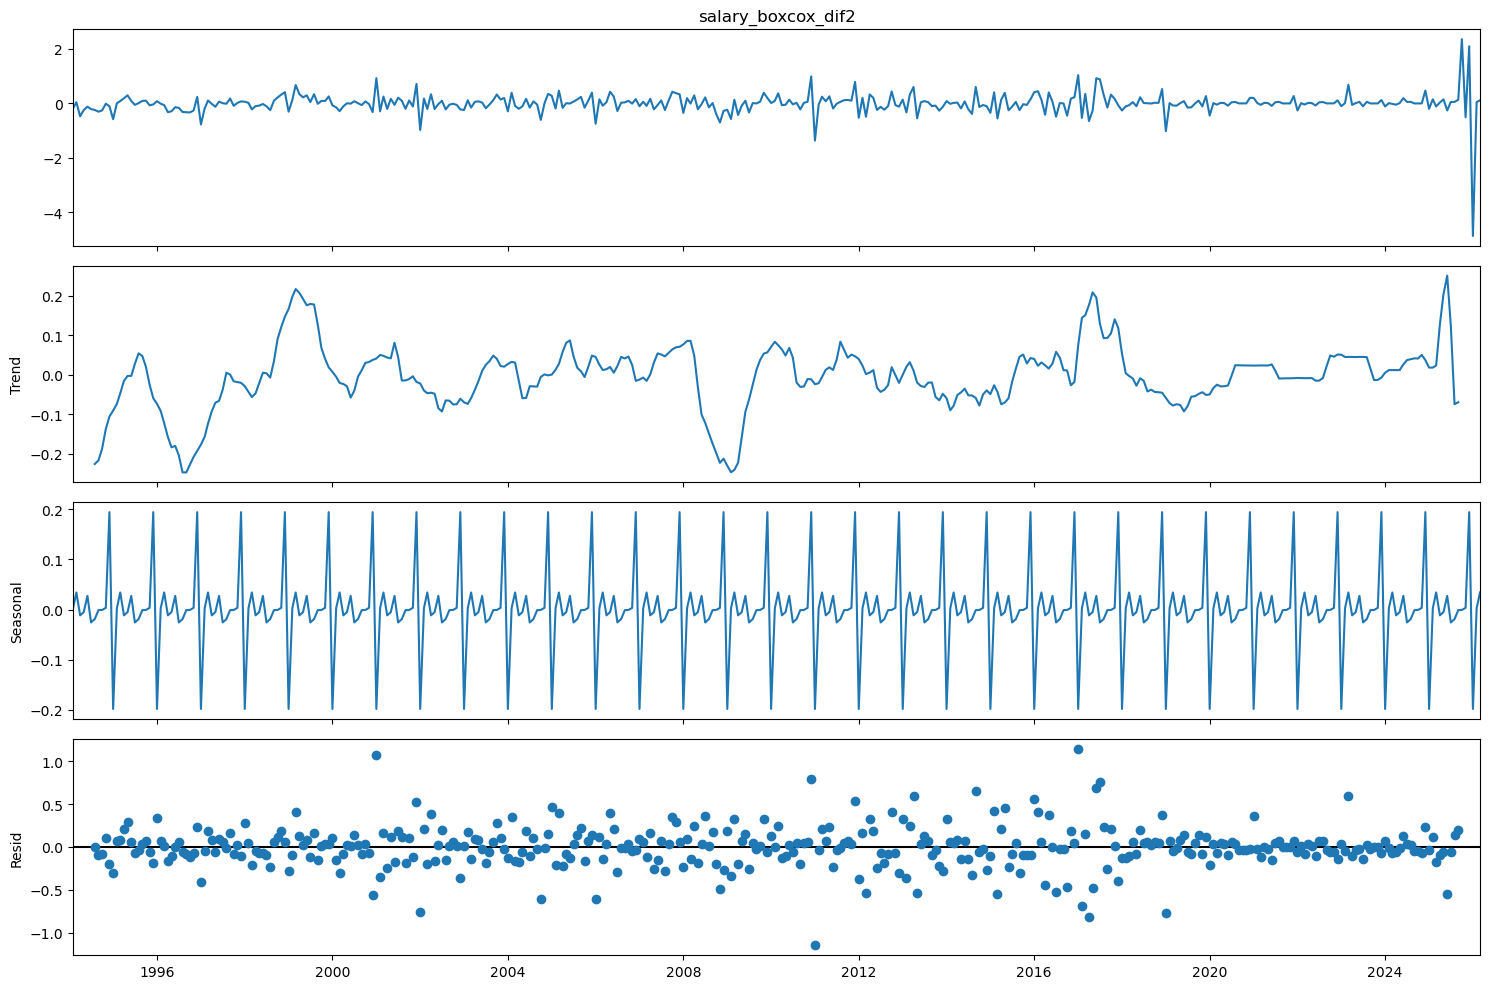

In [49]:
df['salary_boxcox_dif2'] = df.salary_boxcox_dif - df.salary_boxcox_dif.shift(1)
plt.figure(figsize(15,10))
sm.tsa.seasonal_decompose(df.salary_boxcox_dif2[13:]).plot() 
plt.show()

In [50]:


print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(df.salary_boxcox_dif2[13:])[1])


Критерий Дики-Фуллера: p=0.000000


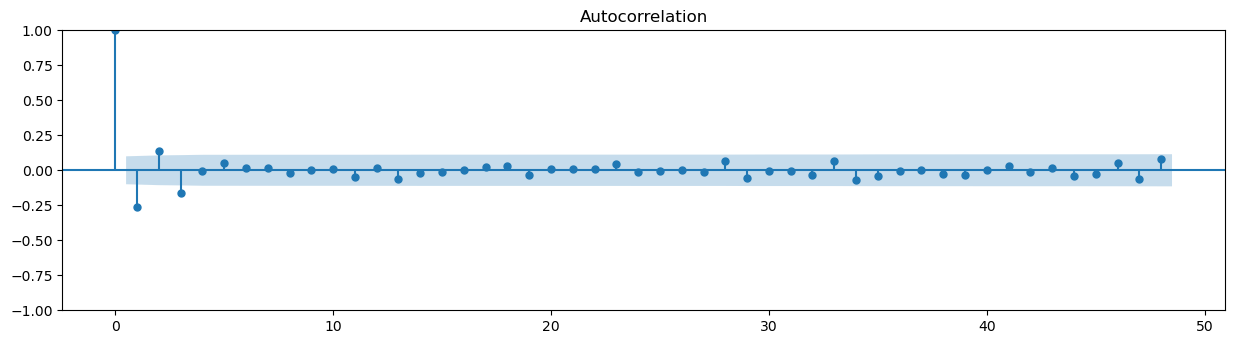

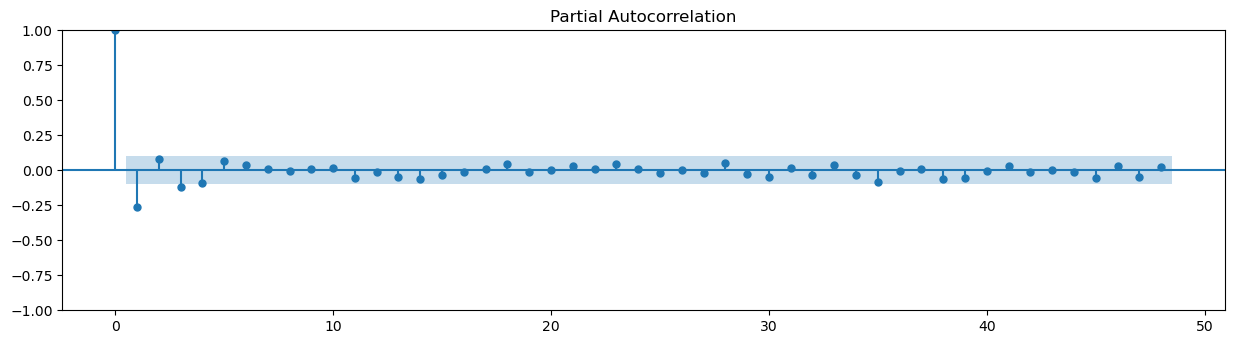

In [51]:
plt.figure(figsize(15,8))
ax = plt.subplot(211)
sm.graphics.tsa.plot_acf(df.salary_boxcox_dif2[13:].values.squeeze(), lags=48, ax=ax)
pylab.show()
ax = plt.subplot(212)
sm.graphics.tsa.plot_pacf(df.salary_boxcox_dif2[13:].values.squeeze(), lags=48, ax=ax)
pylab.show()

In [52]:
best = auto_arima(
    df.salary_boxcox_dif2.dropna(),
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    information_criterion='aic'
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=372.060, Time=0.53 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=393.472, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=370.025, Time=0.09 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=373.641, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=391.791, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=368.189, Time=0.02 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=370.023, Time=0.08 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=372.012, Time=0.10 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=367.851, Time=0.03 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=369.787, Time=0.16 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=369.786, Time=0.18 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=371.777, Time=0.17 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=360.966, Time=0.04 sec
 ARIMA(3,0,0)(1,0,0)[12] intercept   : AIC=362.845, Time=0.17 sec
 ARIMA(3,0,0)(0,0,1)[12] intercep

In [53]:
print(f"order={best.order}, seasonal_order={best.seasonal_order}")

# order=(p, d, q) - несезонная часть
# seasonal_order=(P, D, Q, s)  сезонная часть

# Q = 0
# q = 1
# P = 0
# p = 5

order=(5, 0, 1), seasonal_order=(0, 0, 0, 12)


In [54]:
ps = range(3, 7)
d=1
qs = range(0, 3)
Ps = range(0, 2)
D=1
Qs = range(0, 2)

In [55]:
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
print("Всего комбинаций параметров:", len(parameters_list))

Всего комбинаций параметров: 48


In [56]:

%%time
results = []
best_aic = float("inf")
warnings.filterwarnings('ignore')

for param in parameters_list:
    #try except нужен, потому что на некоторых наборах параметров модель не обучается
    try:
        model=sm.tsa.statespace.SARIMAX(df.salary_boxcox, order=(param[0], d, param[1]), 
                                        seasonal_order=(param[2], D, param[3], 12)).fit(disp=-1)
    #выводим параметры, на которых модель не обучается и переходим к следующему набору
    except ValueError:
        print('wrong parameters:', param)
        continue
    aic = model.aic
    #сохраняем лучшую модель, aic, параметры
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])
    
warnings.filterwarnings('default')

CPU times: user 2min 42s, sys: 3min 19s, total: 6min 2s
Wall time: 38.9 s


In [57]:

result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())

      parameters         aic
44  (6, 2, 0, 0)  352.092261
47  (6, 2, 1, 1)  353.779891
45  (6, 2, 0, 1)  353.977358
28  (5, 1, 0, 0)  355.402640
24  (5, 0, 0, 0)  355.434296


In [58]:
print(best_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                       salary_boxcox   No. Observations:                  399
Model:             SARIMAX(6, 1, 2)x(0, 1, [], 12)   Log Likelihood                -167.046
Date:                             Sun, 15 Mar 2026   AIC                            352.092
Time:                                     22:16:16   BIC                            387.695
Sample:                                 01-01-1993   HQIC                           366.211
                                      - 03-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4127      0.133     10.642      0.000       1.152       1.673
ar.L2         -0.3856      

Критерий Стьюдента: p=0.490450
Критерий Дики-Фуллера: p=0.000000


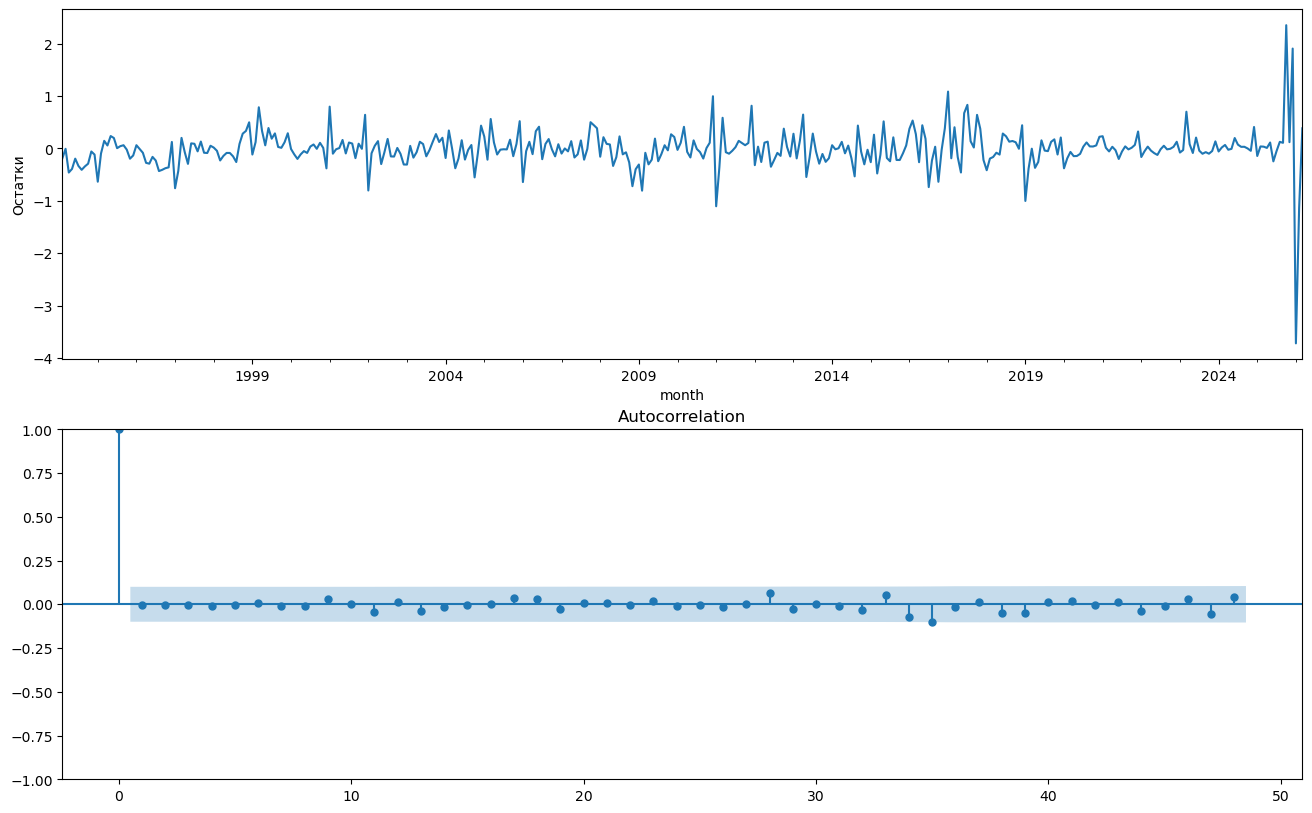

In [59]:

plt.figure(figsize(16,10))
plt.subplot(211)
best_model.resid[13:].plot()
plt.ylabel(u'Остатки')

ax = plt.subplot(212)
sm.graphics.tsa.plot_acf(best_model.resid[13:].values.squeeze(), lags=48, ax=ax)

print("Критерий Стьюдента: p=%f" % stats.ttest_1samp(best_model.resid[13:], 0)[1])
print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(best_model.resid[13:])[1])

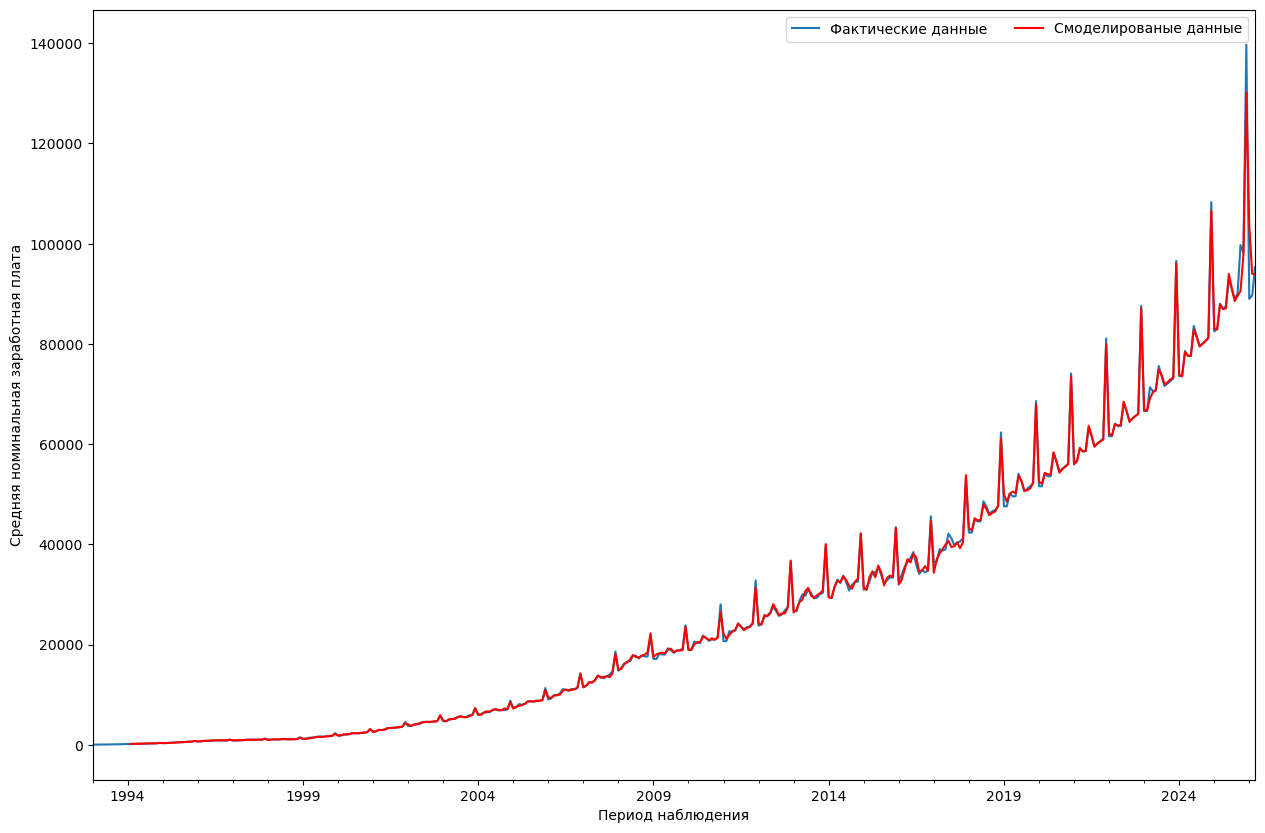

In [ ]:

warnings.filterwarnings('ignore')
df['model'] = invboxcox(best_model.fittedvalues, lmbda)
plt.figure(figsize(15,10))
plot1 = df.salary.plot()
plot2 = df.model[13:].plot(color='r')
plt.ylabel(u'Средняя заработная плата')
plt.xlabel(u'Период наблюдения')
plt.legend( [u'Фактические данные', u'Смоделированые данные'], loc=1, ncol = 2, prop={'size':10})
pylab.show()
warnings.filterwarnings('default')

/var/folders/pk/9xprbn3n0l976phskwjq30ww0000gn/T/ipykernel_8784/144700493.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df2 = pd.concat([df2, future])


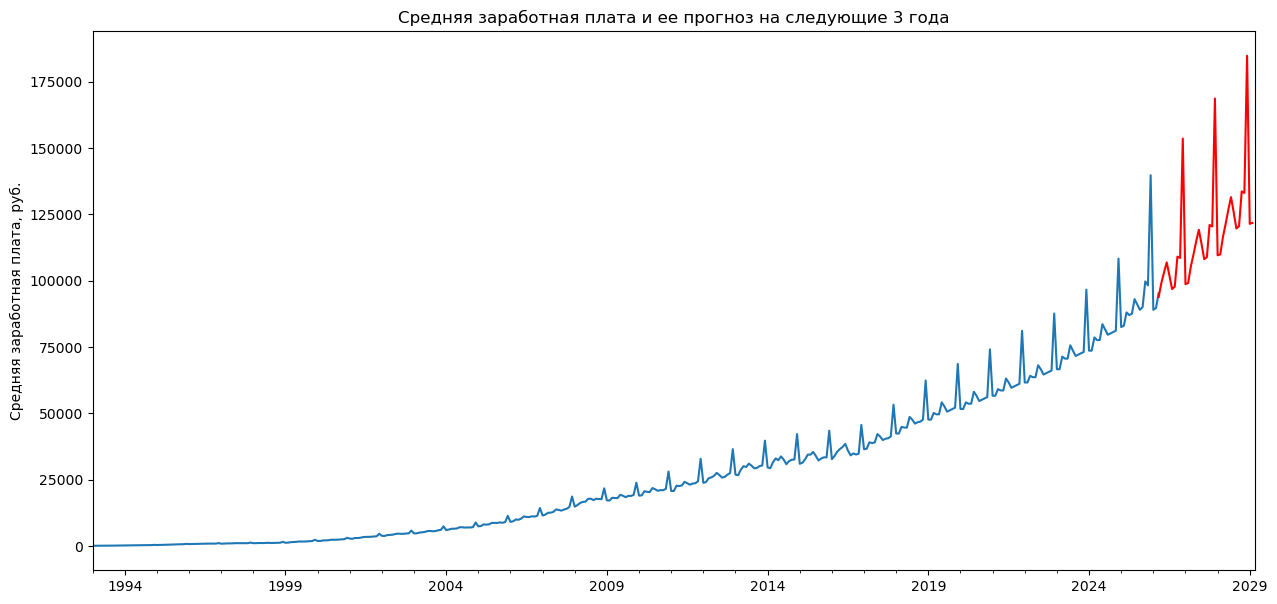

In [63]:
df2 = df[['salary']]
date_list = [datetime.datetime.strptime("2026-04-01", "%Y-%m-%d") + relativedelta(months=x) for x in range(0,36)]
future = pd.DataFrame(index=date_list, columns= df2.columns)
df2 = pd.concat([df2, future])
df2['forecast'] = invboxcox(best_model.predict(start = 398, end=433), lmbda)

plt.figure(figsize(15,7))
df2.salary.plot()
df2.forecast.plot(color='r')
plt.ylabel(u'Средняя заработная плата, руб.')
plt.title(u'Средняя заработная плата и ее прогноз на следующие 3 года')
pylab.show()

In [64]:
print(df2['forecast'].dropna().round(0).astype(int))

2026-03-01     93839
2026-04-01     99090
2026-05-01    103100
2026-06-01    106864
2026-07-01    101974
2026-08-01     96828
2026-09-01     97694
2026-10-01    109021
2026-11-01    108555
2026-12-01    153565
2027-01-01     98655
2027-02-01     99086
2027-03-01    105285
2027-04-01    109868
2027-05-01    114780
2027-06-01    119163
2027-07-01    113844
2027-08-01    108074
2027-09-01    108837
2027-10-01    120969
2027-11-01    120418
2027-12-01    168654
2028-01-01    109553
2028-02-01    109893
2028-03-01    116480
2028-04-01    121388
2028-05-01    126702
2028-06-01    131473
2028-07-01    125824
2028-08-01    119670
2028-09-01    120536
2028-10-01    133627
2028-11-01    133073
2028-12-01    184768
2029-01-01    121411
2029-02-01    121765
Name: forecast, dtype: int64
